In [1]:
!pip install kaggle
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip creditcardfraud.zip

Saving creditcard.csv.zip to creditcard.csv.zip
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:04<00:00, 15.1MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print(df.shape)
print(df["Class"].value_counts())
print(df["Class"].value_counts(normalize=True)*100)

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [4]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud Amount statistikasi:")
print(fraud['Amount'].describe())
print("\nNormal Amount statistikasi:")
print(normal['Amount'].describe())

Fraud Amount statistikasi:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Amount statistikasi:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


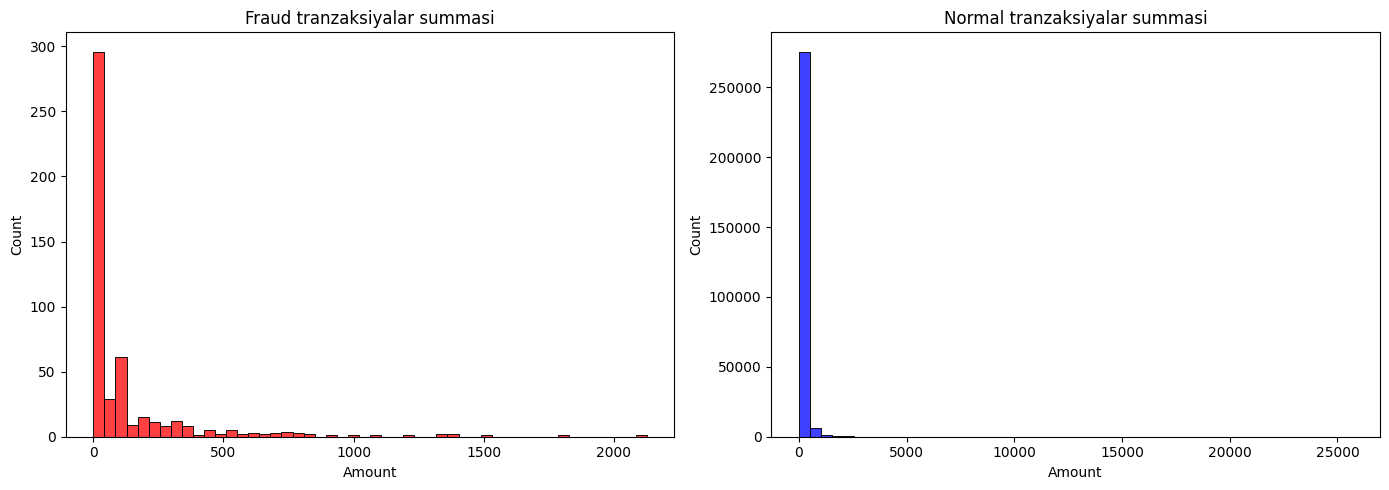

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(fraud['Amount'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Fraud tranzaksiyalar summasi')

sns.histplot(normal['Amount'], bins=50, ax=axes[1], color='blue')
axes[1].set_title('Normal tranzaksiyalar summasi')

plt.tight_layout()
plt.show()

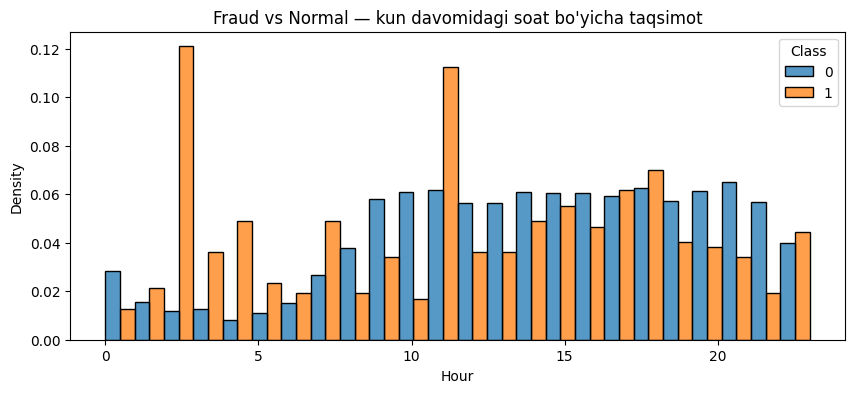

In [6]:
df['Hour'] = (df['Time'] // 3600) % 24

plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Hour', hue='Class', bins=24, multiple='dodge', stat='density', common_norm=False)
plt.title('Fraud vs Normal — kun davomidagi soat bo\'yicha taqsimot')
plt.show()

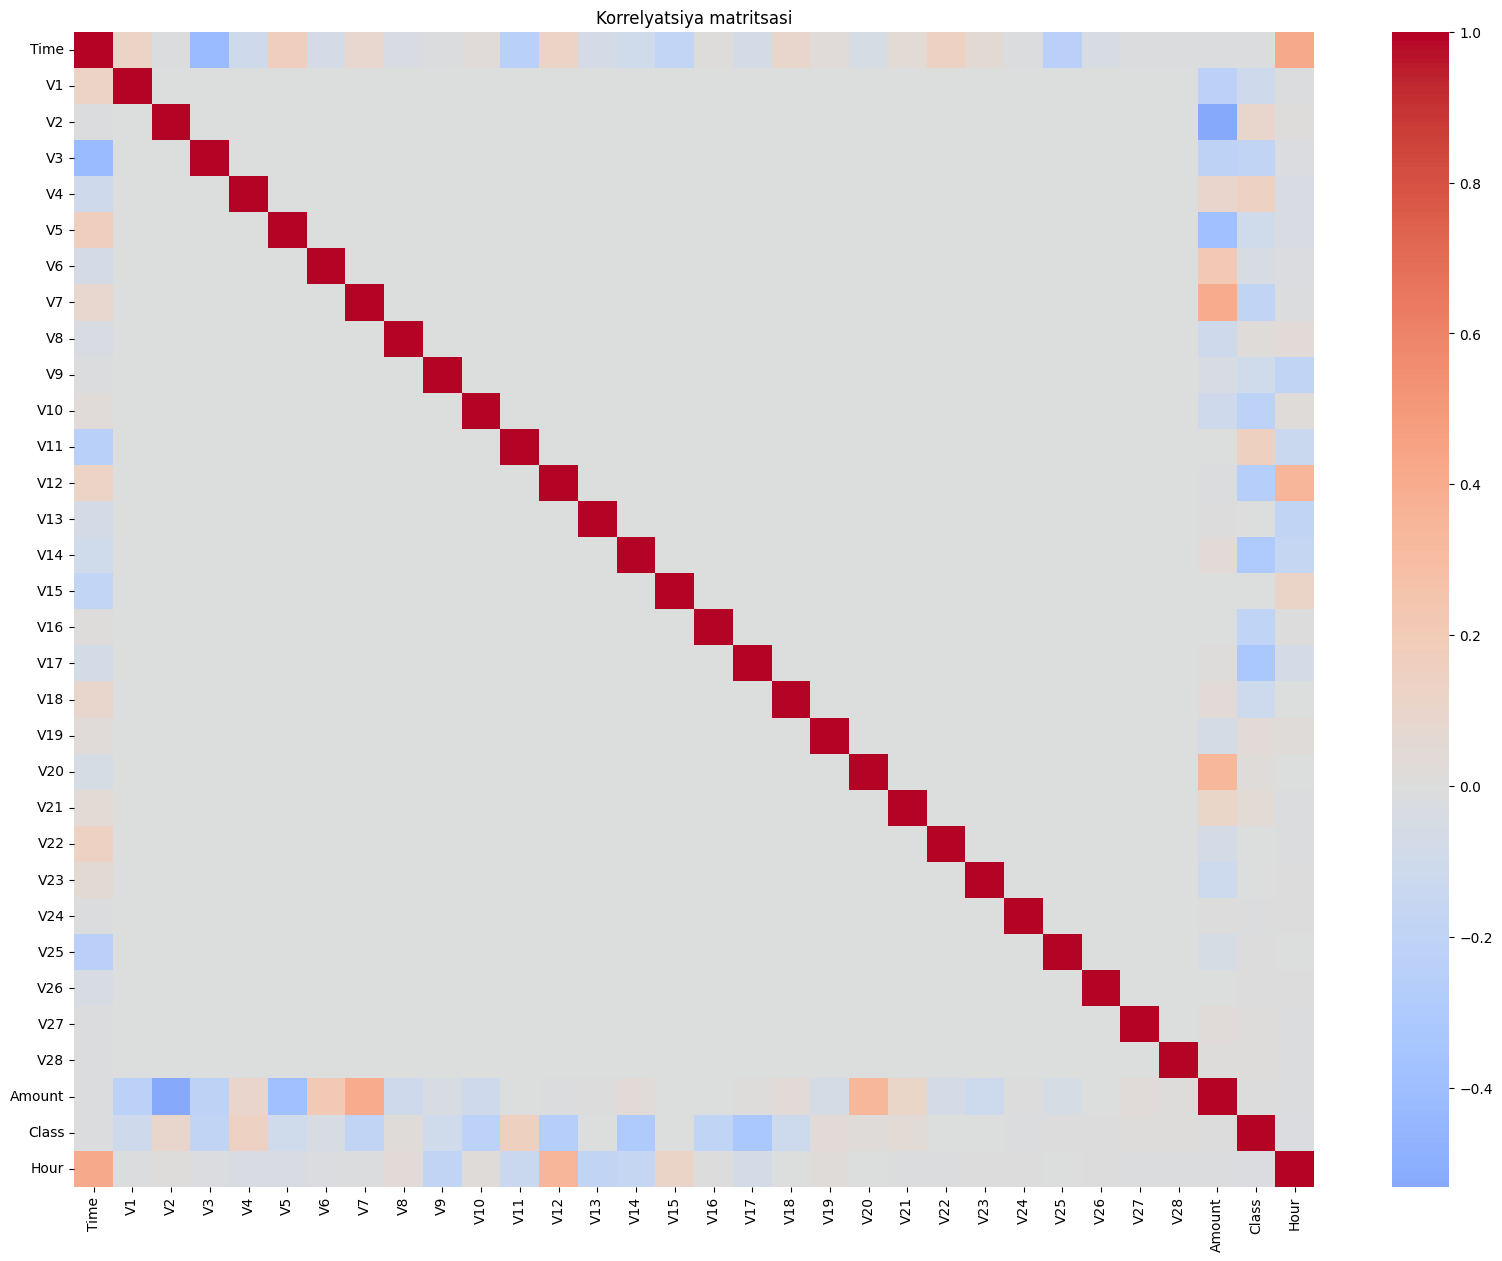

In [7]:
plt.figure(figsize=(20,15))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Korrelyatsiya matritsasi')
plt.show()

In [8]:
corr_with_class = df.corr()['Class'].sort_values(ascending=False)
print(corr_with_class)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
Hour     -0.017109
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [9]:
!pip install imbalanced-learn -q

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class', 'Hour'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train'da fraud soni:", y_train.sum())
print("Test'da fraud soni:", y_test.sum())

Train shape: (227845, 30)
Test shape: (56962, 30)
Train'da fraud soni: 394
Test'da fraud soni: 98


In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("SMOTE'dan keyin train shape:", X_train_smote.shape)
print("SMOTE'dan keyin fraud/normal nisbati:")
print(y_train_smote.value_counts())

SMOTE'dan keyin train shape: (454902, 30)
SMOTE'dan keyin fraud/normal nisbati:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.90      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score: 0.9759745414766919


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


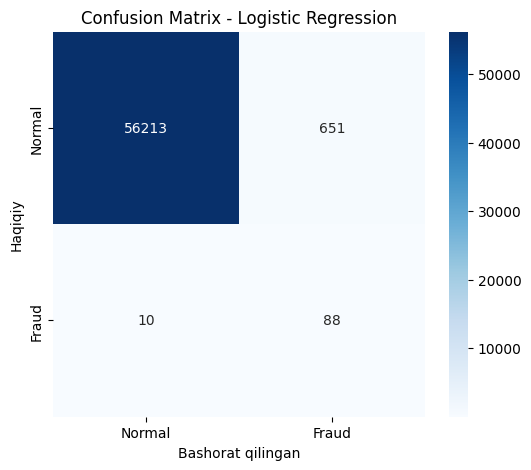

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Bashorat qilingan')
plt.ylabel('Haqiqiy')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest - Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest - ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba_rf))

Random Forest - Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.83      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Random Forest - ROC-AUC Score: 0.9644234399584257


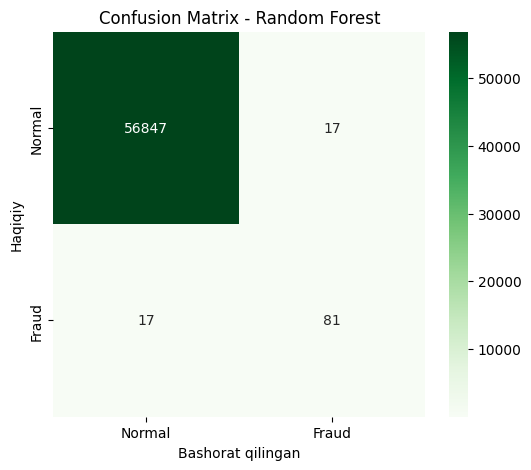

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.xlabel('Bashorat qilingan')
plt.ylabel('Haqiqiy')
plt.title('Confusion Matrix - Random Forest')
plt.show()

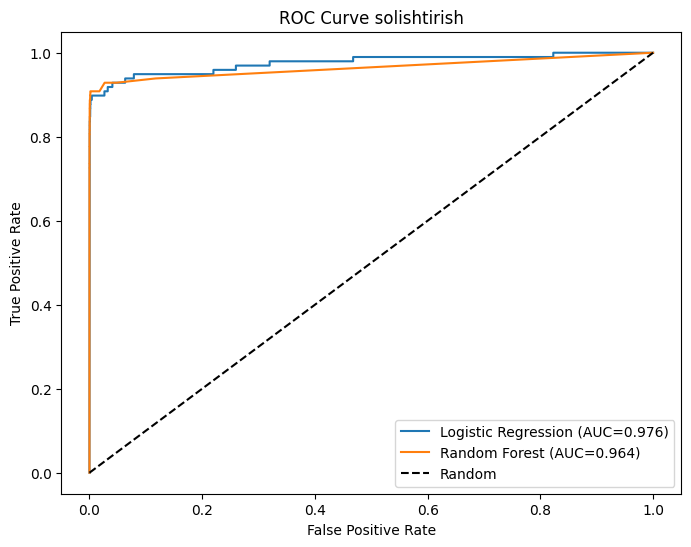

In [15]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_pred_proba):.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_pred_proba_rf):.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve solishtirish')
plt.legend()
plt.show()

In [18]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print(f"True Negative (to'g'ri aniqlangan normal): {tn}")
print(f"False Positive (noto'g'ri fraud deb belgilangan): {fp}")
print(f"False Negative (o'tkazib yuborilgan fraud): {fn}")
print(f"True Positive (to'g'ri aniqlangan fraud): {tp}")

True Negative (to'g'ri aniqlangan normal): 56847
False Positive (noto'g'ri fraud deb belgilangan): 17
False Negative (o'tkazib yuborilgan fraud): 17
True Positive (to'g'ri aniqlangan fraud): 81


In [19]:
#Test to'plamidagi fraud tranzaksiyalarning Miqdorlari
test_df = X_test.copy()
test_df['Class'] = y_test
test_df['Predicted'] = y_pred_rf

#O'tkazib yuborilgan fraudlar (False Negative) - bank yo'qotgan pul
missed_fraud = test_df[(test_df['Class']==1) & (test_df['Predicted']==0)]
caught_fraud = test_df[(test_df['Class']==1) & (test_df['Predicted']==1)]
false_alarms = test_df[(test_df['Class']==0) & (test_df['Predicted']==1)]

print(f"Ushlangan fraud summasi: ${caught_fraud['Amount'].sum():,.2f}")
print(f"O'tkazib yuborilgan fraud summasi: ${missed_fraud['Amount'].sum():,.2f}")
print(f"Noto'g'ri bloklangan (haqiqiy mijozlar) tranzaksiyalar soni: {len(false_alarms)}")
print(f"Noto'g'ri bloklangan summa: ${false_alarms['Amount'].sum():,.2f}")

Ushlangan fraud summasi: $6,741.66
O'tkazib yuborilgan fraud summasi: $3,903.27
Noto'g'ri bloklangan (haqiqiy mijozlar) tranzaksiyalar soni: 17
Noto'g'ri bloklangan summa: $1,604.13


In [20]:
cost_per_false_positive = 5  #taxminiy support/noroziligi xarajati
total_savings = caught_fraud['Amount'].sum() - (len(false_alarms) * cost_per_false_positive)
print(f"Model orqali taxminiy sof foyda: ${total_savings:,.2f}")

Model orqali taxminiy sof foyda: $6,656.66


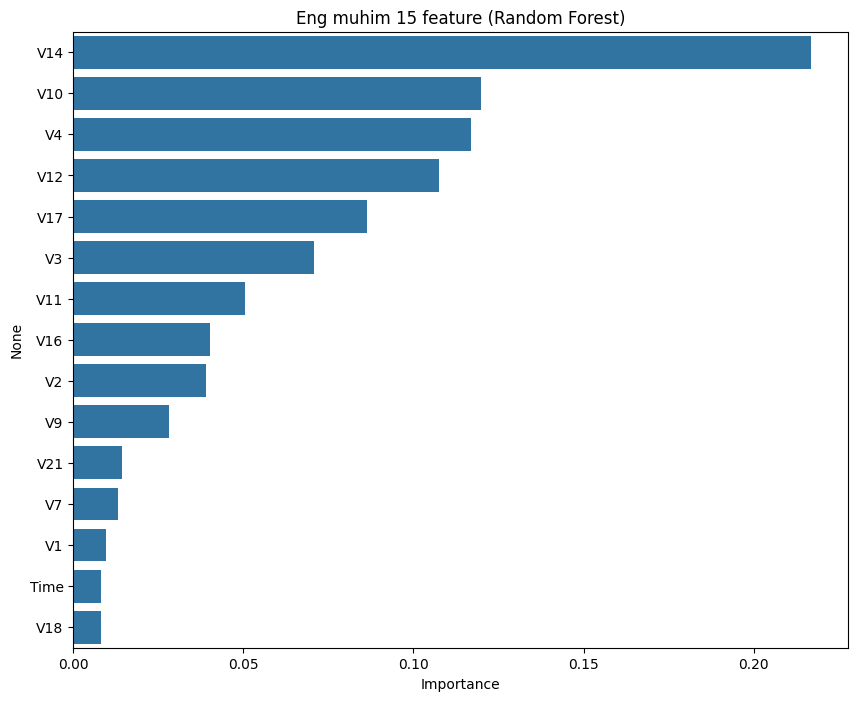

V14     0.216978
V10     0.119804
V4      0.116792
V12     0.107548
V17     0.086269
V3      0.070823
V11     0.050492
V16     0.040146
V2      0.038889
V9      0.028260
V21     0.014422
V7      0.013014
V1      0.009725
Time    0.008097
V18     0.008017
dtype: float64


In [21]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index)
plt.title('Eng muhim 15 feature (Random Forest)')
plt.xlabel('Importance')
plt.show()

print(importances.head(15))